# 04 - Model Optimization
---
**Objective:** Improve the performance of the selected model (XGBoost) through hyperparameter tuning and optimization techniques.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

# Add project root to path
import os
import sys
sys.path.append(os.path.abspath('../'))
from src.data.loader import load_csv
from src.models.trainer import split_data, encoding, class_weights, clean_feature_names
from src.models.evaluator import evaluate_model, evaluate_threshold
from src.models.optimization import find_optimal_threshold

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Libraries imported successfully!")
print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Python version: 3.13.5
Pandas version: 2.3.1
NumPy version: 2.3.2


In [2]:
# Load data
train = load_csv('../data/external/train_top_features.csv')
print()
test = load_csv('../data/external/test_top_features.csv')

👉 Loading: ../data/external/train_top_features.csv
DATASET INFORMATION
Shape: 1,296,675 rows × 10 columns
Memory usage: 150.87 MB

Column types:
int64      6
float64    3
object     1
Name: count, dtype: int64

Missing values: 0

👉 Loading: ../data/external/test_top_features.csv
DATASET INFORMATION
Shape: 555,719 rows × 10 columns
Memory usage: 64.66 MB

Column types:
int64      6
float64    3
object     1
Name: count, dtype: int64

Missing values: 0


In [3]:
X_train, y_train = split_data(train)
X_test,  y_test  = split_data(test)

X_train = clean_feature_names(X_train)
X_test  = clean_feature_names(X_test)

X_train, X_test = encoding(X_train, X_test)
scale_pos_weight = class_weights(y_train)

Feature shape: (1296675, 9)
scale_pos_weight: 171.75


## A. Threshold Optimization

In [ ]:
# Train baseline XGBoost (notebook-3 best params)
baseline = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'
)
baseline.fit(X_train, y_train)

evaluate_model(baseline, X_test, y_test)


-- Model --
  Precision : 0.6563
  Recall    : 0.8625
  F2-score  : 0.8115
  ROC-AUC   : 0.99653
  PR-AUC    : 0.88719
Confusion Matrix:
[[552605    969]
 [   295   1850]]


  Optimal threshold (F2 score) for XGBoost
  Threshold : 0.7842
  Precision : 0.7980
  Recall    : 0.8289
  F2 score : 0.8225
  Confusion Matrix @ threshold=0.7842
[[553124    450]
 [   367   1778]]


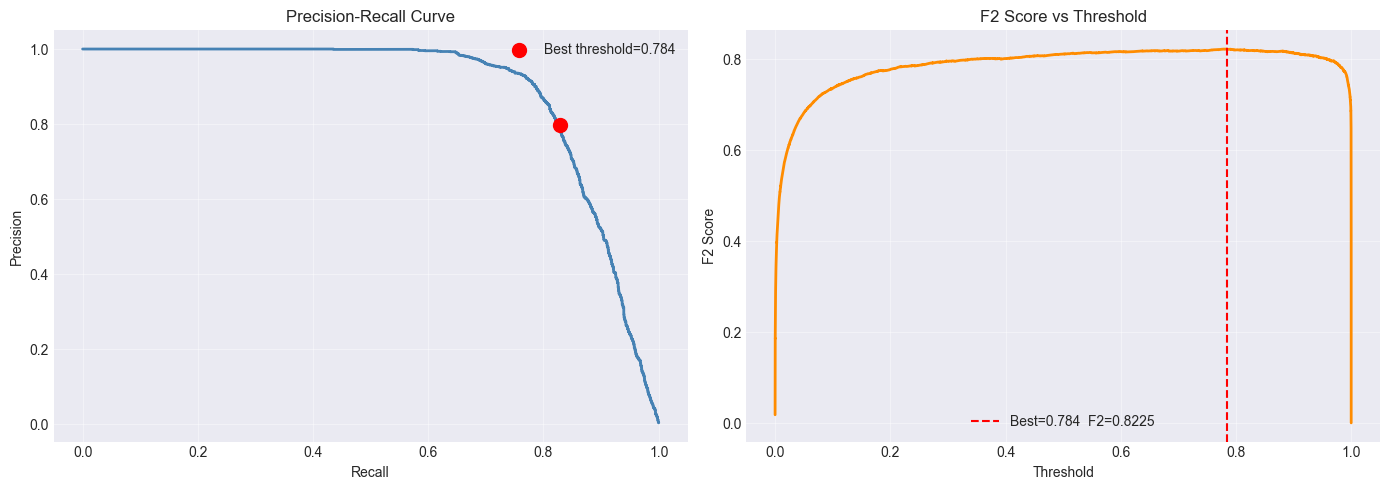

In [5]:
# Run threshold search
# beta=2: recall is 2x more important than precision (typical for fraud)
best_thr = find_optimal_threshold(baseline, X_test, y_test, beta=2, name="XGBoost")

## B. Hyperparameter Tuning with Optuna

In [ ]:
def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 200, 1000, step=100),
        'max_depth'         : trial.suggest_int('max_depth', 4, 12),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma'             : trial.suggest_float('gamma', 0.0, 5.0),
        # fixed
        'scale_pos_weight'  : scale_pos_weight,
        'random_state'      : 42,
        'n_jobs'            : -1,
        'eval_metric'       : 'aucpr'
        }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    return average_precision_score(y_test, y_prob)


# Run study
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest PR-AUC : {study.best_value:.5f}")
print(f"Best params : {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best PR-AUC : 0.89739
Best params : {'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.023995776775647334, 'subsample': 0.9731760313452497, 'colsample_bytree': 0.9408707632196446, 'min_child_weight': 15, 'reg_alpha': 0.20187961125422263, 'reg_lambda': 0.0007128775295131747, 'gamma': 4.807368069853103}


  Optimal threshold (F2 score) for Tuned XGBoost
  Threshold : 0.9534
  Precision : 0.7620
  Recall    : 0.8508
  F2 score : 0.8314
  Confusion Matrix @ threshold=0.9534
[[553004    570]
 [   320   1825]]


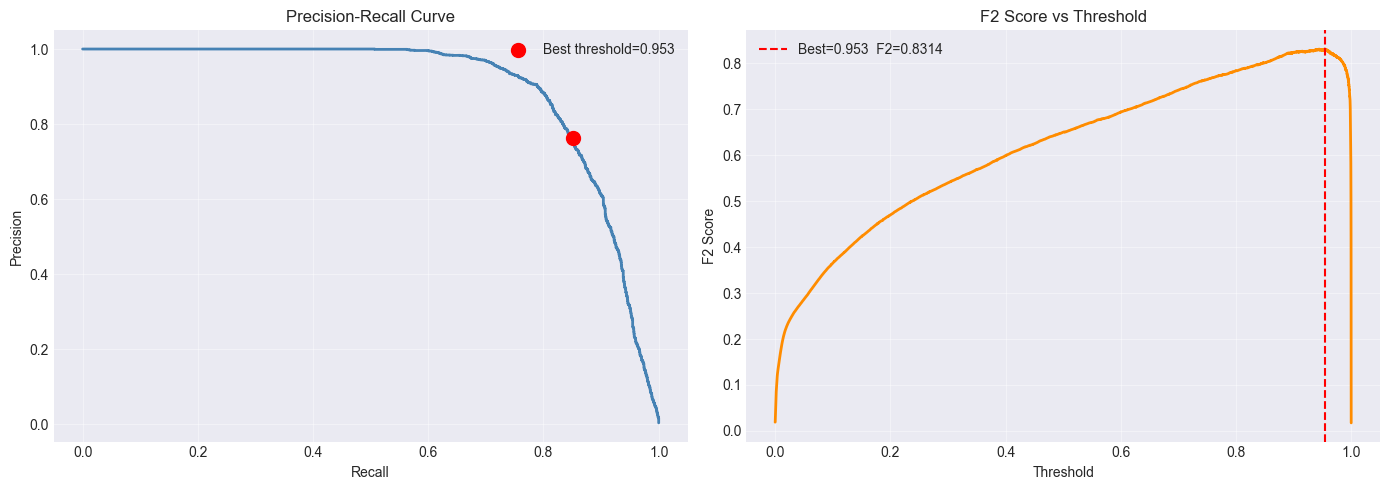

In [ ]:
# Train final model with best params
best_params = {
    'n_estimators'      : 300,
    'max_depth'         : 10,
    'learning_rate'     : 0.024,
    'subsample'         : 0.97,
    'colsample_bytree'  : 0.94,
    'min_child_weight'  : 15,
    'reg_alpha'         : 0.2,
    'reg_lambda'        : 0.0007,
    'gamma'             : 4.8,
    'scale_pos_weight'  : scale_pos_weight,
    'random_state'      : 42,
    'n_jobs'            : -1,
    'eval_metric'       : 'aucpr'
}
tuned_model = XGBClassifier(**best_params)
tuned_model.fit(X_train, y_train)

# Find optimal threshold for tuned model
best_thr_tuned = find_optimal_threshold(tuned_model, X_test, y_test, beta=2, name="Tuned XGBoost")

In [7]:
# Baseline vs Tuned comparison
evaluate_threshold(baseline, X_test, y_test, best_thr, "Baseline XGBoost")
evaluate_threshold(tuned_model, X_test, y_test, best_thr_tuned, "Tuned XGBoost")


-- Baseline XGBoost (Threshold = 0.7841700911521912) --
  Precision : 0.7979
  Recall    : 0.8284
  F2-score  : 0.8222
  ROC-AUC   : 0.99653
  PR-AUC    : 0.88719
Confusion Matrix:
[[553124    450]
 [   368   1777]]

-- Tuned XGBoost (Threshold = 0.9534205794334412) --
  Precision : 0.7619
  Recall    : 0.8503
  F2-score  : 0.8311
  ROC-AUC   : 0.99777
  PR-AUC    : 0.89750
Confusion Matrix:
[[553004    570]
 [   321   1824]]


In [15]:
# Rough cost model
cost_fn = 100   # avg fraud transaction value ($) — missed fraud cost
cost_fp = 10    # investigation cost per false alert ($)

cost_baseline = 368 * cost_fn + 450 * cost_fp
cost_tuned    = 321 * cost_fn + 570 * cost_fp

print(f"Baseline cost : ${cost_baseline:,}")
print(f"Tuned cost    : ${cost_tuned:,}")

Baseline cost : $41,300
Tuned cost    : $37,800


In [ ]:
# Optuna visualisation
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout(); plt.show()

fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout(); plt.show()